In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk(r'C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Recurrent neural network (RNN)\Apple Stock (2013-2018)'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Recurrent neural network (RNN)\Apple Stock (2013-2018)\AAPL - Jan2018.xls
C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Recurrent neural network (RNN)\Apple Stock (2013-2018)\prediksi harga saham apple.ipynb
C:\Users\black\Portofolio\My-Portofolio\Data Scientist\Deep Learning\Recurrent neural network (RNN)\Apple Stock (2013-2018)\.ipynb_checkpoints\Untitled-checkpoint.ipynb


In [2]:
import tensorflow as tf
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import (
    Input, Embedding, LSTM, GRU, SimpleRNN,
    Dense, Dropout, Flatten, BatchNormalization,
    GlobalAveragePooling2D, LeakyReLU
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from tensorflow.keras.layers import LSTM
from tensorflow.keras.layers import Input, LSTM, Dense, Bidirectional, Dropout, BatchNormalization
from tensorflow.keras.layers import Input, LSTM, Bidirectional, Dropout, BatchNormalization, Attention, Add, Dense, LeakyReLU
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Attention
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.regularizers import l2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
import random

In [4]:
# DATA
df = pd.read_csv("AAPL - Jan2018.xls")

In [5]:
df.head()

,Date,Open
0,1/2/2018,170.160004
1,1/3/2018,172.529999
2,1/4/2018,172.539993
3,1/5/2018,173.440002
4,1/8/2018,174.350006


In [6]:
df.isna().sum()

Date    0
Open    0
dtype: int64

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    20 non-null     object 
 1   Open    20 non-null     float64
dtypes: float64(1), object(1)
memory usage: 452.0+ bytes


In [8]:
df.shape

(20, 2)

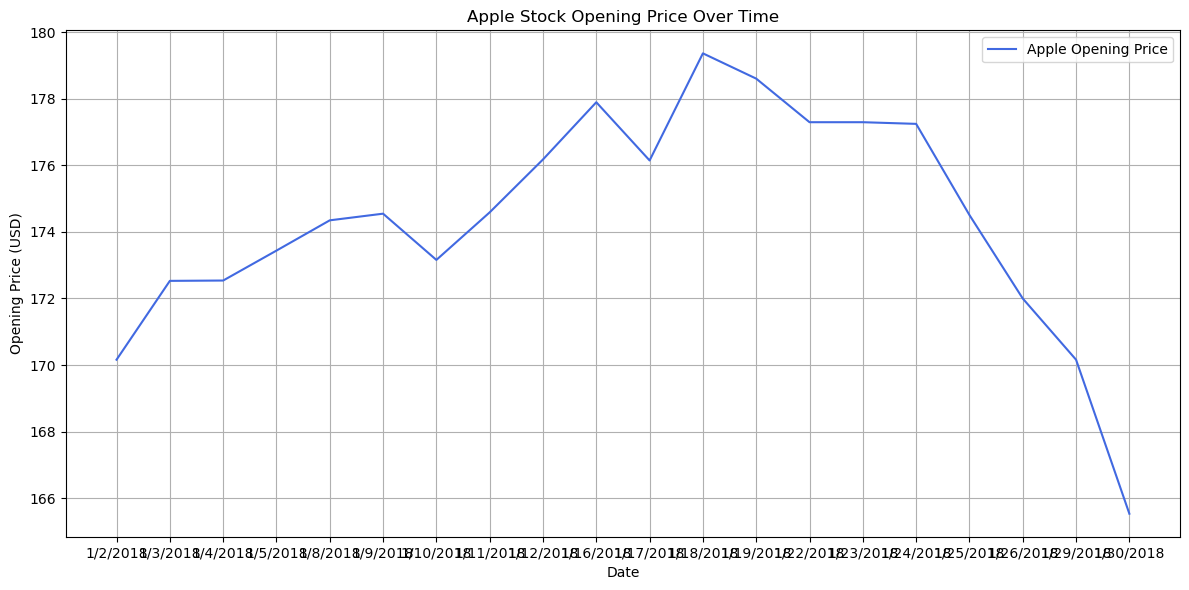

In [9]:
# EDA
plt.figure(figsize=(12, 6))
plt.plot(df['Date'], df['Open'], label='Apple Opening Price', color='royalblue')
plt.title('Apple Stock Opening Price Over Time')
plt.xlabel('Date')
plt.ylabel('Opening Price (USD)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

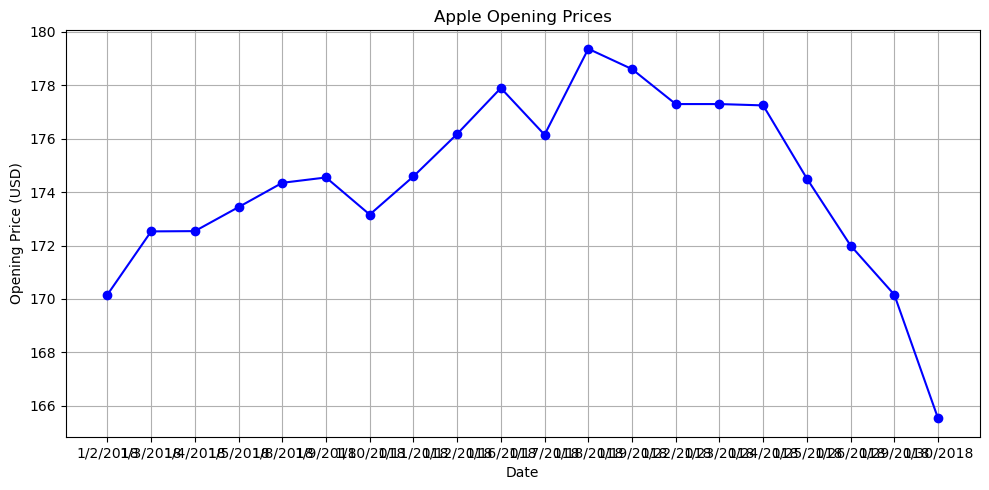

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(df['Date'], df['Open'], marker='o', linestyle='-', color='blue')
plt.title('Apple Opening Prices')
plt.xlabel('Date')
plt.ylabel('Opening Price (USD)')
plt.grid(True)
plt.tight_layout()
plt.show()

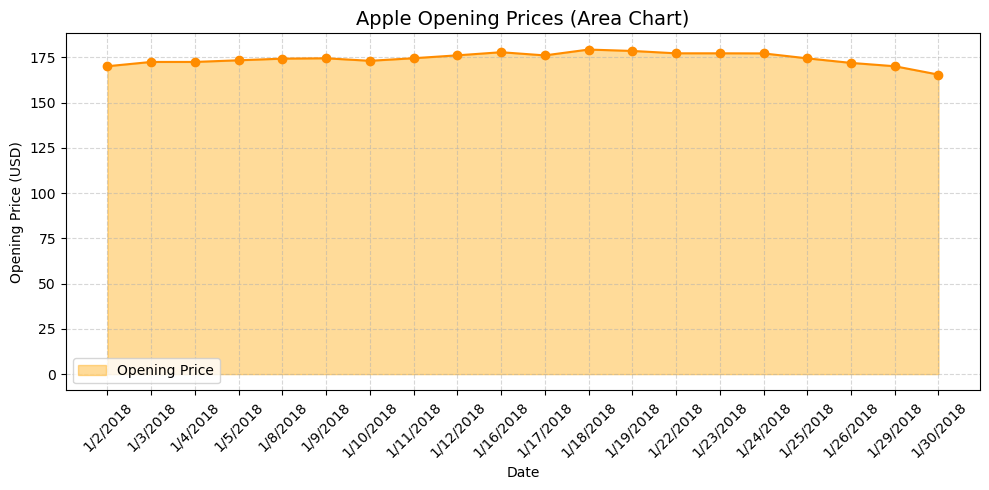

In [11]:
plt.figure(figsize=(10, 5))
plt.fill_between(df['Date'], df['Open'], color='orange', alpha=0.4, label='Opening Price')
plt.plot(df['Date'], df['Open'], color='darkorange', marker='o')
plt.title('Apple Opening Prices (Area Chart)', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Opening Price (USD)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
# SCALER
from sklearn.preprocessing import StandardScaler

open_data = df['Open'].values.reshape(-1, 1)

scaler = StandardScaler()
scaled_open = scaler.fit_transform(open_data)

In [13]:
# DATA STRUCTURE FOR TIME SERIES
def create_sequences(data , window_size):
    X,y = [],[]

    for i in range(len(data) - window_size):
        X.append(data[i:i+window_size])
        y.append(data[i+window_size])
    return np.array(X) , np.array(y)

In [14]:
window_size = 7

X, y = create_sequences(scaled_open, window_size)

In [15]:
X = X.reshape(X.shape[0], X.shape[1], 1)

In [16]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [17]:
# RNN - LSTM MODEL
def lstm_block_with_attention(x,units , return_sequences= False , dropout=0.2):
    residual = x

    x = Bidirectional(LSTM(units, return_sequences=True,kernel_regularizer=l2(0.001)))(x)
    x = Dropout(dropout)(x)
    x = BatchNormalization()(x)

    attention = Attention()([x,x])
    x = Add()([x,attention])

    if residual.shape[-1] != x.shape[-1]:
        residual = Dense(x.shape[-1])(residual)

    x = Add()([x,residual])

    return x

In [18]:
def model_build_lstm_attention(input_shape):
    inputs= Input(shape=input_shape)

    x = lstm_block_with_attention(inputs,512 , return_sequences=True)
    x = lstm_block_with_attention(x , 256 , return_sequences=True)
    x = lstm_block_with_attention(x,128, return_sequences=True)
    x = lstm_block_with_attention(x,64, return_sequences=False)

    for uni , rate in [(512,0.3) , (256,0.3) , (128,0.3) , (64,0.3) , (32,0.3)]:
        x = Dense(uni)(x)
        x = LeakyReLU(alpha=0.01)(x)
        x = Dropout(rate)(x)
    
    outputs = Dense(1)(x)

    model = Model(inputs=inputs , outputs=outputs)

    optimizer = Adam(learning_rate=1e-4)
    model.compile(optimizer,loss="mse",metrics=["mae"])

    return model

In [19]:
model = model_build_lstm_attention((7, 1)) 
model.summary()

D:\APLIKASI\Anaconda\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 7, 1)      │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 7, 1024)   │  2,105,344 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 7, 1024)   │          0 │ bidirectional[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 7, 1024)   │      4,096 │ dropout[0][0]     │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 7, 1024)   │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 7, 1024)   │          0 │ batch_normalizat… │
│                     │                   │            │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 7, 1024)   │      2,048 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 7, 1024)   │          0 │ add[0][0],        │
│                     │                   │            │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 7, 512)    │  2,623,488 │ add_1[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 7, 512)    │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 512)    │      2,048 │ dropout_1[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_1         │ (None, 7, 512)    │          0 │ batch_normalizat… │
│ (Attention)         │                   │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 7, 512)    │          0 │ batch_normalizat… │
│                     │                   │            │ attention_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 7, 512)    │    524,800 │ add_1[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 7, 512)    │          0 │ add_2[0][0],      │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_2     │ (None, 7, 256)    │    656,384 │ add_3[0][0]       │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 7, 256)    │          0 │ bidirectional_2[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 7, 256)    │      1,024 │ dropout_2[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 6,488,961 (24.75 MB)

 Trainable params: 6,485,121 (24.74 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [20]:
Model: "functional"

In [24]:
 print("Total params: 6,488,961 (24.75 MB)")

Total params: 6,488,961 (24.75 MB)


In [25]:
 print("Trainable params: 6,485,121 (24.74 MB)")

Trainable params: 6,485,121 (24.74 MB)


In [26]:
 print("Non-trainable params: 3,840 (15.00 KB)")

Non-trainable params: 3,840 (15.00 KB)


In [27]:
# MODEL FIT
history = model.fit(X_train, y_train, epochs=300, batch_size=32, validation_data=(X_test, y_test))

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 76s 76s/step - loss: 9.3808 - mae: 1.9640 - val_loss: 6.6977 - val_mae: 1.5522
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 678ms/step - loss: 7.2987 - mae: 1.5251 - val_loss: 6.7189 - val_mae: 1.5599
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step - loss: 7.5726 - mae: 1.6100 - val_loss: 6.7364 - val_mae: 1.5663
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step - loss: 8.5273 - mae: 1.7521 - val_loss: 6.7506 - val_mae: 1.5717
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 549ms/step - loss: 7.1473 - mae: 1.5483 - val_loss: 6.7681 - val_mae: 1.5788
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 672ms/step - loss: 8.2038 - mae: 1.5742 - val_loss: 6.7811 - val_mae: 1.5837
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 593ms/step - loss: 6.2163 - mae: 1.3647 - val_loss: 6.7943 - val_mae: 1.5889
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step - loss: 6.7573 - mae: 1.4368 - val_loss: 6.8060 - val_mae: 1.5933
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step - loss: 6.1031

In [28]:
y_pred = model.predict(X_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step
